# PS-S06E07: CatBoost (Pseudo-Labeled)

This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it handles categorical features natively and robustly — particularly useful here since `stress_level`, `sleep_quality`, and `smoking_alcohol` are natural categoricals.

In this notebook we:
- Apply health-domain feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** using **Stratified 5-Fold Cross-Validation**
- Optimize for **Balanced Accuracy**, the primary evaluation metric for this competition
- Collect **Out-of-Fold (OOF) probabilities** and test-set predictions for downstream ensembling

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import time
import random
import warnings

# Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import balanced_accuracy_score
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost_Pseudo',
    use_gpu=True,
    perform_rfe=False,
    perform_optuna_tuning=False
)

# Get the seed and apply it to all internals
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# Target label column
TARGET = 'health_condition'

# Class label mapping (must be consistent everywhere)
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = setup.read_dataset('pseudo')
train_ids = training_df['id'].copy()

PSEUDO DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               sedenta

## Read and Examine the Test Dataset

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering Strategy

We apply a set of feature engineering steps grounded in lifestyle, behavior, and physical health properties:

- `encoding`: Casts categorical variables (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) to CatBoost-native categorical dtype.
- `sleep_stress`: Sleep duration and quality metrics interacting with stress levels.
- `activity_energy`: Step counts, exercise duration, and calorie expenditure interaction ratios.
- `bmi_features`: Body Mass Index indicators and category mappings.
- `risk_score`: Calculated composite health risk index based on unhealthy behavior combinations.
- `missing_flags`: Explicit boolean indicator flags for missing values in survey columns.
- `numeric_expansion`: Mathematical expansions (log, square, square root) of continuous indicators.

**Categorical handling**: `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, and `gender` are passed directly to CatBoost as categoricals. CatBoost learns ordered statistics over them natively without one-hot encoding.

In [5]:
# Define which feature engineering strategies to use
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion'
]

In [6]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(int)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
print(f'Target sample: {y.head()}')
display(X.head())

Performing initial feature engineering.
Feature Count: 59
CatBoost categorical features (7): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']
Target sample: 0    1
1    0
2    1
3    1
4    0
Name: health_condition, dtype: int64


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,is_original,is_missing_sleep_duration,is_missing_heart_rate,is_missing_bmi,is_missing_calorie_expenditure,is_missing_step_count,is_missing_exercise_duration,is_missing_water_intake,is_missing_diet_type,is_missing_stress_level,is_missing_sleep_quality,is_missing_physical_activity_level,is_missing_smoking_alcohol,is_missing_gender,sleep_quality_index,sleep_to_stress_ratio,sleep_shortage,calories_per_step,calories_per_exercise_min,steps_per_exercise_min,exercise_intensity_proxy,bmi_category,bmi_x_calories,bmi_per_step,lifestyle_risk_score,Log_sleep_duration,sleep_duration_sq,sleep_duration_sqrt,Log_heart_rate,heart_rate_sq,heart_rate_sqrt,Log_bmi,bmi_sq,bmi_sqrt,Log_calorie_expenditure,calorie_expenditure_sq,calorie_expenditure_sqrt,Log_step_count,step_count_sq,step_count_sqrt,Log_exercise_duration,exercise_duration_sq,exercise_duration_sqrt,Log_water_intake,water_intake_sq,water_intake_sqrt
0,5.220,70.600,25.660,"2,174.000","1,326.000",19.800,1.860,veg,high,average,sedentary,yes,female,False,0,0,0,0,0,0,0,0,0,0,0,0,0,10.440,1.740,2.780,1.638,104.519,63.750,19.800,overweight,"55,784.840",0.019,5.000,1.828,27.248,2.285,4.271,"4,984.360",8.402,3.283,658.436,5.066,7.685,"4,726,276.000",46.626,7.191,"1,758,276.000",36.414,3.035,392.040,4.450,1.051,3.460,1.364
1,5.530,71.300,25.840,"1,966.000","9,891.000",49.900,1.260,non-veg,low,average,moderate,yes,other,False,0,0,0,0,0,0,0,0,0,0,0,0,0,11.060,5.530,2.470,0.199,38.625,194.322,99.800,overweight,"50,801.440",0.003,3.000,1.876,30.581,2.352,4.281,"5,083.690",8.444,3.290,667.706,5.083,7.584,"3,865,156.000",44.340,9.199,"97,831,881.000",99.454,3.930,"2,490.010",7.064,0.815,1.588,1.122
2,5.290,75.400,24.540,"2,688.000","14,216.000",38.100,1.600,veg,high,poor,active,yes,male,False,0,0,0,0,0,0,0,0,0,0,0,0,0,5.290,1.763,2.710,0.189,68.747,363.581,114.300,normal,"65,963.520",0.002,4.000,1.839,27.984,2.300,4.336,"5,685.160",8.683,3.240,602.212,4.954,7.897,"7,225,344.000",51.846,9.562,"202,094,656.000",119.231,3.666,"1,451.610",6.173,0.956,2.560,1.265
3,4.700,77.200,23.130,"2,630.000","7,174.000",59.900,2.020,veg,high,average,active,occasional,female,False,0,0,0,0,0,0,0,0,0,0,0,0,0,9.400,1.567,3.300,0.367,43.186,117.800,179.700,normal,"60,831.900",0.003,2.000,1.740,22.090,2.168,4.359,"5,959.840",8.786,3.183,534.997,4.809,7.875,"6,916,900.000",51.284,8.878,"51,466,276.000",84.699,4.109,"3,588.010",7.740,1.105,4.080,1.421
4,7.230,73.400,28.440,"2,560.000","6,584.000",46.000,2.250,veg,NaN,average,sedentary,NaN,male,False,0,0,0,0,0,0,0,0,1,0,0,1,0,14.460,NaN,0.770,0.389,54.468,140.085,46.000,overweight,"72,806.400",0.004,2.000,2.108,52.273,2.689,4.309,"5,387.560",8.567,3.382,808.834,5.333,7.848,"6,553,600.000",50.596,8.793,"43,349,056.000",81.142,3.850,"2,116.000",6.782,1.179,5.062,1.500


In [7]:
# Resolve categorical column list to those actually present after engineering
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as strings or integer codes. We use strings.
for c in cat_cols:
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

Categorical Features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']


### Feature Selection (CatBoost Native)

CatBoost's built-in `select_features` uses SHAP values to iteratively remove the weakest features. This is more appropriate than sklearn RFECV here because it respects the native categorical encoding and uses the same gradient-boosted objective as the final model.

The selection runs on a stratified holdout split (not full CV) for speed, then the selected feature names are applied per-fold during training to prevent leakage.

In [8]:
n_jobs = 1 if setup.use_gpu() else -1
rfe_filename = 'selected_features_catboost_pseudo.json'

optimal_cols = X.columns

if setup.perform_rfe():
    print('Running CatBoost native feature selection (RecursiveByShapValues)...')

    FS_STEPS = 20
    FS_EVAL_SPLIT = 0.2

    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_fs = fe_fs.fit_transform(training_df)
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Cast cats to string for CatBoost
    for c in cat_features_fs:
        if c in X_fs.columns:
            X_fs[c] = X_fs[c].astype(str)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_fs, y))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    fs_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1:average=Macro',
        classes_count=3,
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        feature_border_type='UniformAndQuantiles',
        border_count=254,
        random_seed=seed,
        auto_class_weights='Balanced',
        task_type='GPU' if setup.use_gpu() else 'CPU',
        verbose=200,
        early_stopping_rounds=100,
        allow_writing_files=False,
    )

    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),
        # num_features_to_select=int(X_tr_fs.shape[1] * 0.70),  # keep 70% (tune: 0.6–0.9)
        num_features_to_select=52,  # Hardcoded to catch peak feature count from earlier run
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level="Verbose",
        plot=False
    )

    print("\nEliminated Features:", fs_result['eliminated_features_names'])
    print("Selected Features count:", len(fs_result['selected_features_names']))

    loss_graph = fs_result['loss_graph']
    print("Loss values at each step:", loss_graph['loss_values'])

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]
    print(f"\nSelected {len(optimal_cols)} / {X_fs.shape[1]} features.")

    setup.save_rfe(rfe_filename, pd.Index(optimal_cols))
else:
    optimal_cols = setup.load_rfe(rfe_filename, X)

Loaded 22 features from selected_features_catboost_pseudo.json


### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **Balanced Accuracy**.

- **Objective**: Arithmetic mean of class-specific recall scores across at-risk, unhealthy, and fit.
- **Weights**: `auto_class_weights='Balanced'` ensures the model does not ignore any stellar class.
- **Validation**: Each trial runs a 5-fold stratified CV loop for robustness.

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")
skf_cache = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
fold_fe = []

# Only split on competition rows; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx  = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf_cache.split(comp_idx, y.iloc[comp_idx])):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx   = comp_idx[rel_val_idx]
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = training_df.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    if optimal_cols is not None:
        final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    cat_features_fold = fe.get_cat_features(X_train_trans)
    if optimal_cols is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]

    for c in cat_features_fold:
        X_train_trans[c] = X_train_trans[c].astype(str)
        X_val_trans[c]   = X_val_trans[c].astype(str)

    fold_fe.append(fe)
    fold_cache.append((
        Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold),
        Pool(X_val_trans,   y_val_fold,   cat_features=cat_features_fold),
        y_val_fold,
        val_idx,
        final_cols,
        cat_features_fold
    ))

print(f"Cached {len(fold_cache)} folds.")

Precomputing fold-wise FE for Optuna (once)...
Cached 5 folds.


In [10]:
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
print(f'cols_to_keep: {cols_to_keep}')

# Only import if needed.
if setup.use_gpu():
    import torch
    
def objective(trial):
    trial_start = time.perf_counter()
    
    params = {
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1:average=Macro',
        'classes_count': 3,
        'auto_class_weights': 'Balanced',
        'iterations': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 8.0),
        'one_hot_max_size': 10,
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 1000, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 5, 15),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.65, 1.0),
        'feature_border_type': 'UniformAndQuantiles',
        'border_count': 254,
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }
    
    grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide'])
    params['grow_policy'] = grow_policy
    if grow_policy == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 24, 96)
        params['boosting_type'] = 'Plain'

    oof_preds = np.full(len(y), -1, dtype=int)  # -1 sentinel: unfilled = not in any val fold

    for fold, (train_pool, val_pool, y_val_fold, val_idx, final_cols, cat_features_fold) in enumerate(fold_cache):
        fold_start = time.perf_counter()

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=300,
            verbose=False
        )

        fold_elapsed = time.perf_counter() - fold_start
        n_trees = model.tree_count_
        ms_per_tree = (fold_elapsed / n_trees) * 1000 if n_trees else float('nan')

        val_preds = model.predict(val_pool).flatten()
        oof_preds[val_idx] = val_preds
        fold_score = balanced_accuracy_score(y_val_fold, val_preds)

        print(f'  Fold {fold+1}: {fold_elapsed:6.1f}s | trees={n_trees:5d} '
              f'| {ms_per_tree:6.2f} ms/tree | bal_acc={fold_score:.5f} '
              f'| grow={grow_policy}, lei={params["leaf_estimation_iterations"]}, '
              f'depth={params["depth"]}')

        del model
        gc.collect()
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    trial_elapsed = time.perf_counter() - trial_start
    # Only score competition rows that were actually held out
    filled_mask = oof_preds >= 0
    overall = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
    print(f'Trial {trial.number}: {trial_elapsed/60:.1f} min total | OOF bal_acc={overall:.5f}\n')
    return overall

Training shape: (719663, 59)
cols_to_keep: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'sleep_quality_index', 'sleep_to_stress_ratio', 'sleep_shortage', 'calories_per_step', 'calories_per_exercise_min', 'steps_per_exercise_min', 'exercise_intensity_proxy', 'bmi_x_calories', 'bmi_per_step', 'lifestyle_risk_score']


In [11]:
# Load the "best" parameters that were calculated in an earlier Optuna run
optuna_filename = 'optuna_params_catboost_pseudo.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print('Starting CatBoost Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    study = optuna.create_study(
        storage='sqlite:///catboost_pseudo_study.db',
        load_if_exists=True,
        study_name='cb_predict_student_health_risk_optuna',
        direction='maximize',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,
        )
    )

    # Seed the study with last best parameters.
    study.enqueue_trial(best_params)
    
    study.optimize(
        objective,
        n_trials=25,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best Score:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params

    setup.save_optuna_params(optuna_filename, best_params)
else:
    print('\nUsing pretuned params (run Optuna for new tuned values):')
    print(best_params)

Loaded 9 parameters from optuna_params_catboost_pseudo.json
Starting CatBoost Optuna Optimization...


[I 2026-07-16 15:45:50,744] Using an existing study with name 'cb_predict_student_health_risk_optuna' instead of creating a new one.


  0%|          | 0/25 [00:00<?, ?it/s]

  Fold 1:    5.9s | trees=   86 |  68.21 ms/tree | bal_acc=0.95767 | grow=Lossguide, lei=7, depth=6


  Fold 2:    9.2s | trees=  350 |  26.21 ms/tree | bal_acc=0.95646 | grow=Lossguide, lei=7, depth=6


...

  Fold 1:    7.2s | trees=  535 |  13.43 ms/tree | bal_acc=0.95782 | grow=Lossguide, lei=6, depth=4


  Fold 2:    4.8s | trees=  245 |  19.63 ms/tree | bal_acc=0.95614 | grow=Lossguide, lei=6, depth=4


  Fold 3:    7.3s | trees=  554 |  13.12 ms/tree | bal_acc=0.95689 | grow=Lossguide, lei=6, depth=4


  Fold 4:   11.3s | trees= 1053 |  10.78 ms/tree | bal_acc=0.95579 | grow=Lossguide, lei=6, depth=4


  Fold 5:    7.7s | trees=  601 |  12.87 ms/tree | bal_acc=0.95549 | grow=Lossguide, lei=6, depth=4
Trial 49: 0.7 min total | OOF bal_acc=0.95643

[I 2026-07-16 16:09:34,854] Trial 49 finished with value: 0.9564285437472169 and parameters: {'learning_rate': 0.07288789815659431, 'depth': 4, 'l2_leaf_reg': 2.841957455003554, 'random_strength': 2.105742063975586, 'min_data_in_leaf': 107, 'leaf_estimation_iterations': 6, 'subsample': 0.9771810772268984, 'grow_policy': 'Lossguide', 'max_leaves': 95}. Best is trial 23 with value: 0.9566964189048917.
Best Score: 0.9566964189048917
Best Params: {'learning_rate': 0.0551247131620829, 'depth': 6, 'l2_leaf_reg': 5.147036728783163, 'random_strength': 1.7148832443890722, 'min_data_in_leaf': 58, 'leaf_estimation_iterations': 7, 'subsample': 0.7727145201690047, 'grow_policy': 'Lossguide', 'max_leaves': 66}
Saved 9 parameters to optuna_params_catboost_pseudo.json


### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation score
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is Balanced Accuracy on the full OOF vector across all three stellar classes.

In [12]:
metric_period = 20

cb_tuned_params = {
    **best_params,
    'iterations': 16000,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1:average=Macro',
    'classes_count': 3,
    'auto_class_weights': 'Balanced',
    'bootstrap_type': 'Bernoulli',
    'feature_border_type': 'UniformAndQuantiles',
    'border_count': 254,
    'one_hot_max_size': 10,
    'gpu_ram_part': 0.65,
    'allow_writing_files': False,
    'verbose': 200,
    'metric_period': metric_period,
    'task_type': 'GPU' if setup.use_gpu() else 'CPU',
}

if cb_tuned_params.get('grow_policy') == 'Lossguide':
    cb_tuned_params['boosting_type'] = 'Plain'

print('Final CatBoost CV Training with 5-Seed Averaging')
print('================================================')
print('Parameters used for training:')
print(cb_tuned_params)

seeds = setup.seed()

eval_results = []
models = []

oof_probs_all = np.zeros((len(y), 3), dtype=np.float64)
test_probs_all = np.zeros((len(test_df), 3), dtype=np.float64)

for s_idx, current_seed in enumerate(seeds):
    print(f'\n' + '='*60)
    print(f'SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed}')
    print('='*60)
    setup.set_seeds(current_seed)
    
    # Recompute folds and features for this seed
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    comp_mask = training_df['is_original'] == False
    comp_idx  = np.where(comp_mask)[0]
    
    seed_fold_cache = []
    seed_fold_fe = []
    
    for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
        train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
        val_idx   = comp_idx[rel_val_idx]
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold   = training_df.iloc[val_idx]
        y_val_fold   = y.iloc[val_idx]

        fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=current_seed)
        X_train_trans = fe.fit_transform(X_train_fold)
        X_val_trans   = fe.transform(X_val_fold)

        if optimal_cols is not None:
            final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]

        cat_features_fold = fe.get_cat_features(X_train_trans)
        if optimal_cols is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]

        for c in cat_features_fold:
            X_train_trans[c] = X_train_trans[c].astype(str)
            X_val_trans[c]   = X_val_trans[c].astype(str)

        seed_fold_fe.append(fe)
        seed_fold_cache.append((
            Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold),
            Pool(X_val_trans,   y_val_fold,   cat_features=cat_features_fold),
            y_val_fold,
            val_idx,
            final_cols,
            cat_features_fold
        ))

    # Update params for this seed
    current_cb_params = {
        **cb_tuned_params,
        'random_seed': current_seed
    }
    
    # Train models for this seed
    oof_probs_seed = np.zeros((len(y), 3), dtype=np.float64)
    oof_preds_seed = np.full(len(y), -1, dtype=np.int32)
    test_probs_seed = np.zeros((len(test_df), 3), dtype=np.float64)
    
    for fold, (train_pool, val_pool, y_val_fold, val_idx, final_cols, cat_features_fold) in enumerate(seed_fold_cache):
        print(f'Starting fold {fold+1}/5 for seed {current_seed}...')

        # Transform test set using this fold's fitted FeatureFactory
        X_test_trans = seed_fold_fe[fold].transform(test_df)
        X_test_trans = X_test_trans[[c for c in final_cols if c in X_test_trans.columns]]
        for c in cat_features_fold:
            if c in X_test_trans.columns:
                X_test_trans[c] = X_test_trans[c].astype(str)
        test_pool = Pool(X_test_trans, cat_features=cat_features_fold)

        model = cb.CatBoostClassifier(**current_cb_params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=300,
            verbose=200
        )

        # Store all models and learning curves for viz
        eval_results.append(model.get_evals_result())
        models.append(model)

        val_prob = model.predict_proba(val_pool)
        val_pred = model.predict(val_pool).flatten()

        oof_probs_seed[val_idx] = val_prob
        oof_preds_seed[val_idx] = val_pred

        fold_score = balanced_accuracy_score(y_val_fold, val_pred)
        print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

        test_probs_seed += model.predict_proba(test_pool) / 5.0

        del model, test_pool
        gc.collect()
        
    # Log seed-specific score
    filled_mask_seed = oof_preds_seed >= 0
    seed_score = balanced_accuracy_score(y[filled_mask_seed], oof_preds_seed[filled_mask_seed])
    print(f'--- Seed {current_seed} CV Balanced Accuracy: {seed_score:.6f} ---')
    
    # Accumulate predictions
    oof_probs_all += oof_probs_seed
    test_probs_all += test_probs_seed

# Average predictions
oof_probs = oof_probs_all / len(seeds)
test_probs = test_probs_all / len(seeds)

oof_preds = np.argmax(oof_probs, axis=1)
filled_mask = oof_preds >= 0
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
print('\n' + '='*60)
print(f'Seed-Averaged CV Balanced Accuracy: {overall_score:.6f}')
print('='*60)


Final CatBoost CV Training with 5-Seed Averaging
Parameters used for training:
{'learning_rate': 0.0551247131620829, 'depth': 6, 'l2_leaf_reg': 5.147036728783163, 'random_strength': 1.7148832443890722, 'min_data_in_leaf': 58, 'leaf_estimation_iterations': 7, 'subsample': 0.7727145201690047, 'grow_policy': 'Lossguide', 'max_leaves': 66, 'iterations': 16000, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1:average=Macro', 'classes_count': 3, 'auto_class_weights': 'Balanced', 'bootstrap_type': 'Bernoulli', 'feature_border_type': 'UniformAndQuantiles', 'border_count': 254, 'one_hot_max_size': 10, 'gpu_ram_part': 0.65, 'allow_writing_files': False, 'verbose': 200, 'metric_period': 20, 'task_type': 'GPU', 'boosting_type': 'Plain'}

SEED RUN 1/5: seed=10301
Random seed set to: 10301
Starting fold 1/5 for seed 10301...


0:	learn: 0.9486702	test: 0.9500111	best: 0.9500111 (0)	total: 16.9ms	remaining: 4m 30s
200:	learn: 0.9578883	test: 0.9575838	best: 0.9576427 (139)	total: 2.8s	remaining: 3m 39s
400:	learn: 0.9598212	test: 0.9574571	best: 0.9576427 (139)	total: 5.48s	remaining: 3m 33s
bestTest = 0.9576426759
bestIteration = 139
Shrink model to first 140 iterations.
Fold 1 Balanced Accuracy: 0.957643
Starting fold 2/5 for seed 10301...


0:	learn: 0.9485976	test: 0.9485383	best: 0.9485383 (0)	total: 14.4ms	remaining: 3m 50s
200:	learn: 0.9580438	test: 0.9562518	best: 0.9563520 (149)	total: 2.86s	remaining: 3m 45s
400:	learn: 0.9598610	test: 0.9561894	best: 0.9563934 (343)	total: 5.55s	remaining: 3m 35s
600:	learn: 0.9618751	test: 0.9562222	best: 0.9563934 (343)	total: 8.29s	remaining: 3m 32s
bestTest = 0.9563933713
bestIteration = 343
Shrink model to first 344 iterations.
Fold 2 Balanced Accuracy: 0.956369
Starting fold 3/5 for seed 10301...


0:	learn: 0.9486966	test: 0.9483848	best: 0.9483848 (0)	total: 14.7ms	remaining: 3m 54s
200:	learn: 0.9579816	test: 0.9566824	best: 0.9566998 (195)	total: 2.76s	remaining: 3m 37s
400:	learn: 0.9596762	test: 0.9568388	best: 0.9569182 (395)	total: 5.5s	remaining: 3m 34s
600:	learn: 0.9616356	test: 0.9568273	best: 0.9570045 (534)	total: 8.41s	remaining: 3m 35s
800:	learn: 0.9636216	test: 0.9567958	best: 0.9570045 (534)	total: 11.7s	remaining: 3m 41s
bestTest = 0.9570044541
bestIteration = 534
Shrink model to first 535 iterations.
Fold 3 Balanced Accuracy: 0.956975
Starting fold 4/5 for seed 10301...


0:	learn: 0.9489579	test: 0.9475846	best: 0.9475846 (0)	total: 17.5ms	remaining: 4m 39s
200:	learn: 0.9582865	test: 0.9553349	best: 0.9554589 (192)	total: 3.24s	remaining: 4m 14s
400:	learn: 0.9601837	test: 0.9554655	best: 0.9555387 (226)	total: 6.48s	remaining: 4m 11s
600:	learn: 0.9621412	test: 0.9553332	best: 0.9556280 (477)	total: 9.64s	remaining: 4m 7s
bestTest = 0.9556279692
bestIteration = 477
Shrink model to first 478 iterations.
Fold 4 Balanced Accuracy: 0.955583
Starting fold 5/5 for seed 10301...


...

0:	learn: 0.9486304	test: 0.9501041	best: 0.9501041 (0)	total: 14.9ms	remaining: 3m 58s
200:	learn: 0.9578525	test: 0.9575861	best: 0.9576676 (138)	total: 2.88s	remaining: 3m 46s
400:	learn: 0.9595621	test: 0.9576869	best: 0.9577971 (288)	total: 5.69s	remaining: 3m 41s
600:	learn: 0.9614184	test: 0.9578189	best: 0.9578863 (489)	total: 8.62s	remaining: 3m 40s
800:	learn: 0.9636822	test: 0.9578407	best: 0.9579940 (724)	total: 11.4s	remaining: 3m 36s
1000:	learn: 0.9658646	test: 0.9577580	best: 0.9579940 (724)	total: 14.3s	remaining: 3m 34s
bestTest = 0.9579939557
bestIteration = 724
Shrink model to first 725 iterations.
Fold 1 Balanced Accuracy: 0.957965
Starting fold 2/5 for seed 888...


0:	learn: 0.9494099	test: 0.9465959	best: 0.9465959 (0)	total: 15.1ms	remaining: 4m 1s
200:	learn: 0.9585912	test: 0.9546319	best: 0.9547128 (181)	total: 2.86s	remaining: 3m 44s
400:	learn: 0.9603793	test: 0.9546766	best: 0.9547958 (238)	total: 5.56s	remaining: 3m 36s
bestTest = 0.9547958037
bestIteration = 238
Shrink model to first 239 iterations.
Fold 2 Balanced Accuracy: 0.954755
Starting fold 3/5 for seed 888...


0:	learn: 0.9489567	test: 0.9481677	best: 0.9481677 (0)	total: 14.2ms	remaining: 3m 47s
200:	learn: 0.9582321	test: 0.9562630	best: 0.9563036 (195)	total: 2.8s	remaining: 3m 39s
400:	learn: 0.9599507	test: 0.9564658	best: 0.9565737 (368)	total: 5.51s	remaining: 3m 34s
600:	learn: 0.9618684	test: 0.9560862	best: 0.9565737 (368)	total: 8.26s	remaining: 3m 31s
bestTest = 0.9565737291
bestIteration = 368
Shrink model to first 369 iterations.
Fold 3 Balanced Accuracy: 0.956550
Starting fold 4/5 for seed 888...


0:	learn: 0.9490873	test: 0.9502096	best: 0.9502096 (0)	total: 15.1ms	remaining: 4m
200:	learn: 0.9580753	test: 0.9567169	best: 0.9568306 (124)	total: 2.79s	remaining: 3m 39s
400:	learn: 0.9599997	test: 0.9565988	best: 0.9568306 (124)	total: 5.56s	remaining: 3m 36s
bestTest = 0.9568306057
bestIteration = 124
Shrink model to first 125 iterations.
Fold 4 Balanced Accuracy: 0.956823
Starting fold 5/5 for seed 888...


0:	learn: 0.9487894	test: 0.9487117	best: 0.9487117 (0)	total: 16.7ms	remaining: 4m 26s
200:	learn: 0.9580701	test: 0.9571323	best: 0.9571323 (200)	total: 3.08s	remaining: 4m 2s
400:	learn: 0.9598031	test: 0.9569797	best: 0.9571351 (201)	total: 5.96s	remaining: 3m 51s
bestTest = 0.9571351477
bestIteration = 201
Shrink model to first 202 iterations.
Fold 5 Balanced Accuracy: 0.957124
--- Seed 888 CV Balanced Accuracy: 0.956644 ---

Seed-Averaged CV Balanced Accuracy: 0.956579


## Visualizing Model Performance

Diagnostic plots to evaluate how well the model distinguishes between the three stellar classes and to detect potential biases or overfitting.

### Learning Curves (Train vs. Validation Log-Loss)
This plot tracks the metric over boosting iterations. A widening gap between train and validation lines indicates overfitting. Early stopping terminates training once the validation score plateaus.

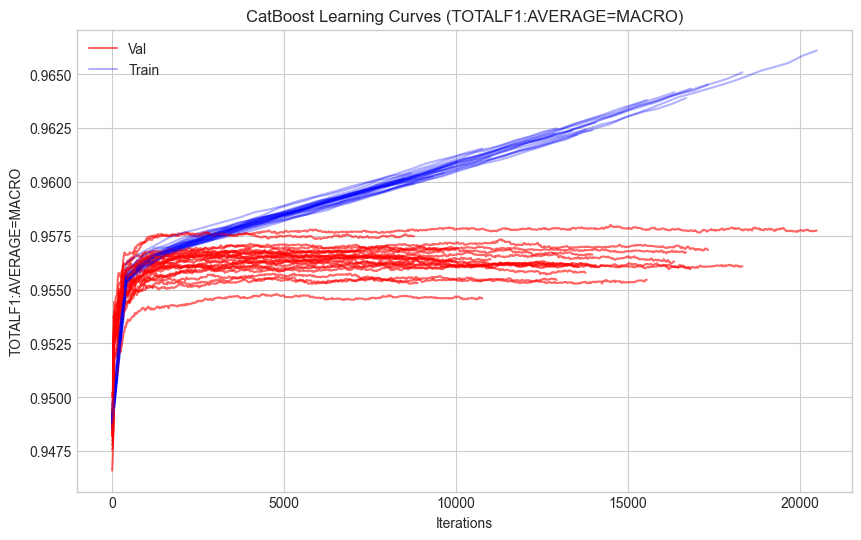

In [13]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='TotalF1:average=Macro', metric_period=metric_period)

### Feature Importance
Average feature importance across folds.
* **Validation check:** lifestyle and body indicators like `bmi`, `sleep_duration`, `step_count`, `stress_level`, `exercise_duration` should dominate.
* **Feature check:** interaction features like `lifestyle_risk_score`, `sleep_quality_index`, and `calories_per_step` should rank highly if their corresponding strategies are active in `fe_strategies`.
* **Leakage check:** `id` must not appear in the chart at all.

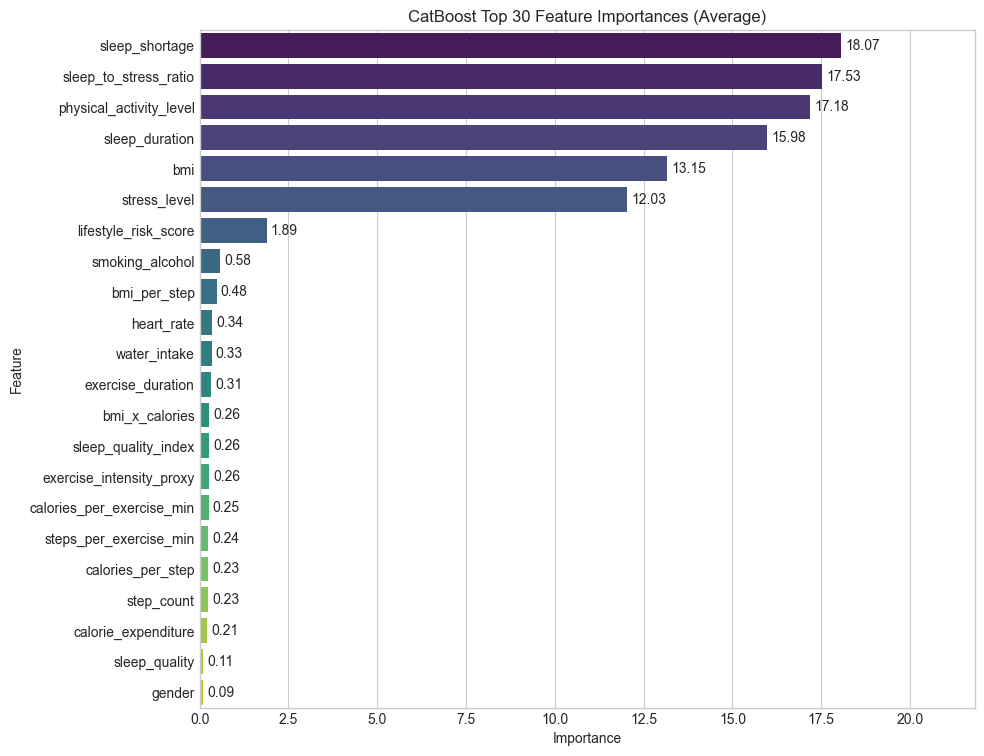

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (at-risk=0, unhealthy=1, fit=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

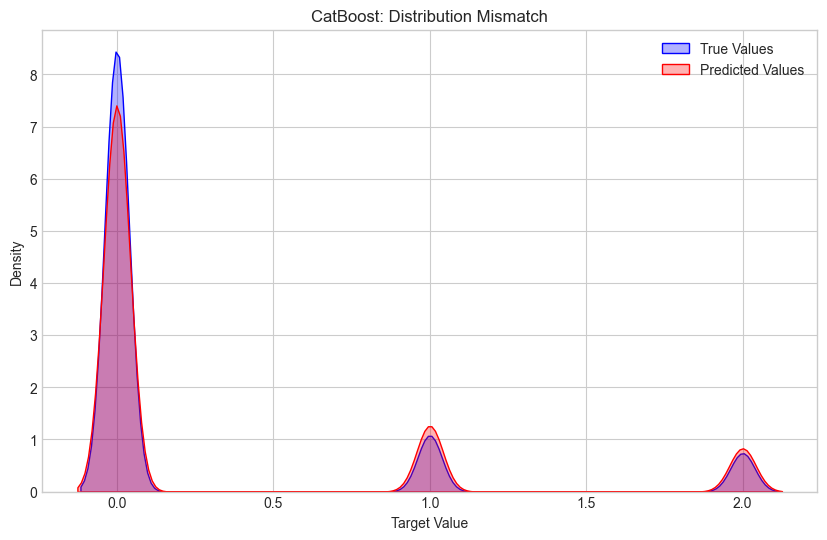

In [15]:
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

### Multiclass ROC Curve (One-vs-Rest)
Each class is treated as the positive class in turn. The AUC for each curve measures how well the model separates that class from the other two. All three curves should sit well above the diagonal; a sagging at-risk or unhealthy curve indicates a struggle to separate the specific risk levels.

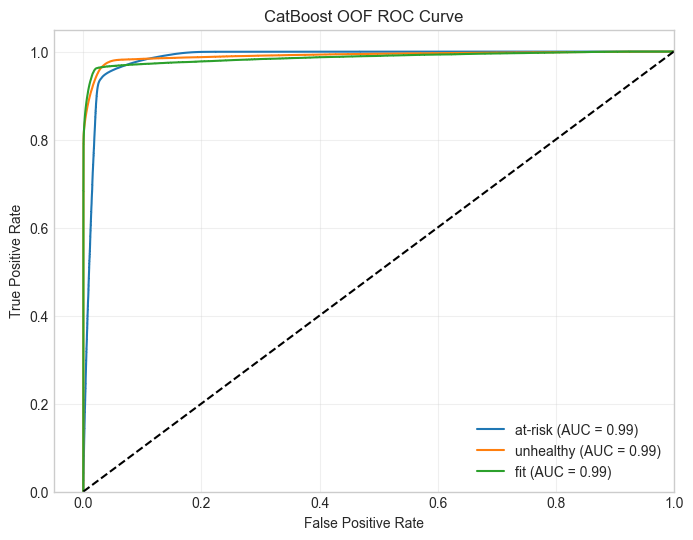

In [16]:
mviz.plot_multiclass_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask], title='CatBoost OOF ROC Curve')

### Confusion Matrix (Out-of-Fold)
Shows which target health classes the model frequently confuses.
* **at-risk (0):** at-risk cases represent students with severe health risk behaviors; off-diagonal entries here are the most critical failures to monitor.
* **unhealthy (1):** unhealthy cases represent moderate risks; off-diagonal values between unhealthy and at-risk are common due to overlapping behavior metrics.
* **fit (2):** fit cases represent healthy behaviors; moderate confusion with unhealthy is expected as behaviors overlap.

Normalized confusion matrix


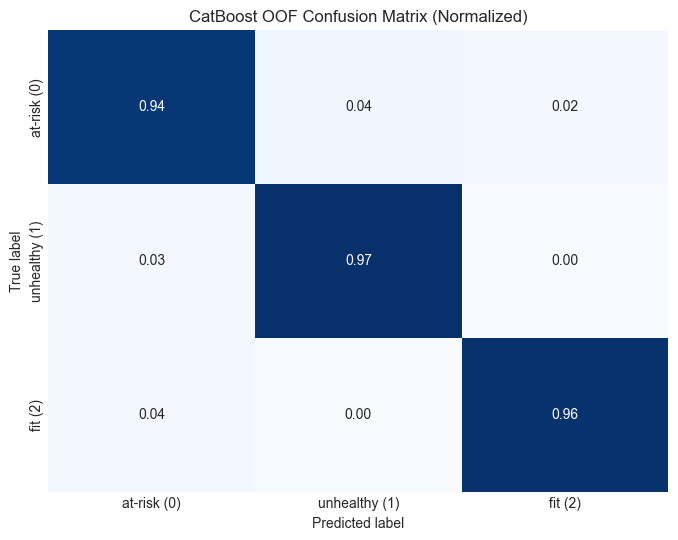

In [17]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='CatBoost OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires the hard predicted class label (`at-risk`, `unhealthy`, or `fit`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [18]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

OOF and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).

For this three-class task we save the full probability distribution across `at-risk`, `unhealthy`, and `fit` rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

In [20]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities — save only competition rows (original rows have no val prediction)
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df = oof_df[filled_mask]  # drop original rows (their probs are all zeros)
oof_df.to_csv(f'{output_dir}/catboost_pseudo_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/catboost_pseudo_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/catboost_pseudo_oof_probs.csv\n - {output_dir}/catboost_pseudo_test_probs.csv')

Saved for ensembling:
 - predictions/catboost_pseudo_oof_probs.csv
 - predictions/catboost_pseudo_test_probs.csv
